In [1]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_parquet("../data/final_df.parquet")
df_phage = df[df["phage_id"] != "NC_000913.3"].copy()
# df = df[df["isSeqSingleton"] == False]
df.head()

,protein_id,namespace,ribosome,embedding,phage_id,description,isPhage,representative_x,seq_cluster_id,isSeqRep,seq_cluster_size,isSeqSingleton,representative_y,struc_cluster_id,isStrucRep,struc_cluster_size,isStrucSingleton
0,NP_415065.1,biological_process,False,"[-23.5926, -93.26165, 53.579185, 34.065807, 40...",NC_000913.3,putative fimbrial usher protein SfmD,False,NP_415065.1,675,True,1,True,NP_417683.1,1514,False,9,False
1,NP_414681.1,biological_process,False,"[7.8664575, -109.593315, 61.22201, 42.282944, ...",NC_000913.3,putative fimbrial usher protein HtrE,False,NP_414681.1,339,True,1,True,NP_417683.1,1514,False,9,False
2,NP_415460.1,biological_process,False,"[-2.407834, -99.97352, 60.042553, 48.969868, 5...",NC_000913.3,putative fimbrial usher protein ElfC,False,NP_415460.1,1032,True,1,True,NP_417683.1,1514,False,9,False
3,NP_417683.1,biological_process,False,"[22.572277, -97.75069, 32.86291, 36.645363, 25...",NC_000913.3,putative fimbrial usher protein YhcD,False,NP_417683.1,3045,True,1,True,NP_417683.1,1514,True,9,False
4,YP_009518785.1,biological_process,False,"[12.542888, -80.09453, 57.51416, -9.444865, 55...",NC_000913.3,fimbrial usher domain-containing protein YdeT,False,YP_009518785.1,8567,True,1,True,YP_009518785.1,5893,True,1,True


# TSNE

In [3]:
X = np.vstack(df["embedding"].values)

tsne = TSNE(n_components=2, random_state=42, perplexity=100, max_iter=1000)
X_tsne = tsne.fit_transform(X)

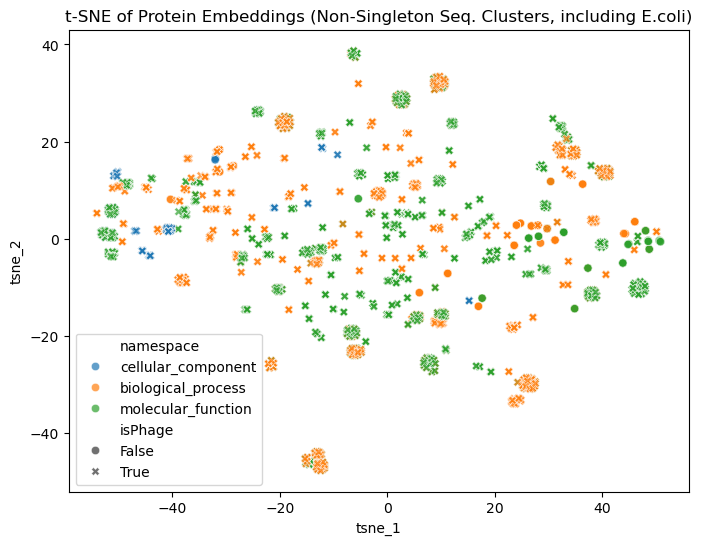

In [4]:
df["tsne_1"] = X_tsne[:, 0]
df["tsne_2"] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="tsne_1",
    y="tsne_2",
    hue="namespace",
    palette="tab10",
    alpha=0.7,
    style="isPhage",
)
plt.title("t-SNE of Protein Embeddings (Non-Singleton Seq. Clusters, including E.coli)")
# plt.legend(title="Namespace")
# plt.legend([], [], frameon=False)
plt.show()

In [5]:
import umap

/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
X = np.vstack(df["embedding"].values)

umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, metric="correlation")
X_umap = umap_model.fit_transform(X)

/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.

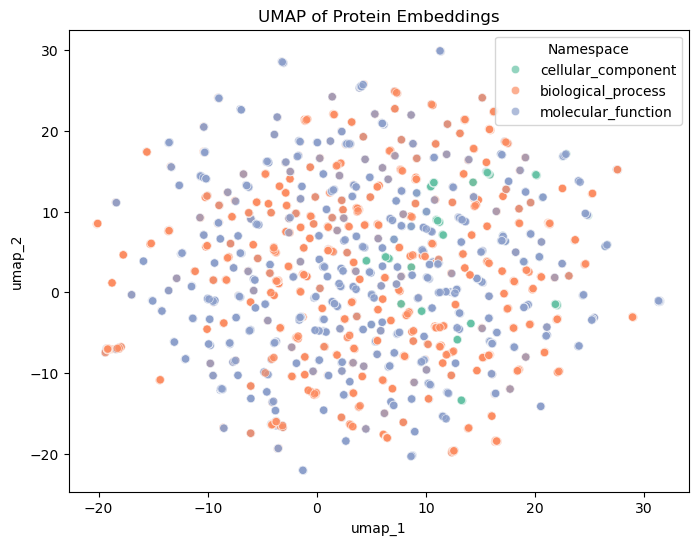

In [7]:
df["umap_1"] = X_umap[:, 0]
df["umap_2"] = X_umap[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="umap_1", y="umap_2", hue="namespace", palette="Set2", alpha=0.7
)
plt.title("UMAP of Protein Embeddings")
plt.legend(title="Namespace")
plt.show()

In [30]:
# Clusters that contain both phage and e.coli proteins
df_non_singleton = df[~df["isStrucSingleton"]]

# group by cluster ID and check composition
cluster_summary = (
    df_non_singleton.groupby("struc_cluster_id")["isPhage"]
    .agg(["any", "all"])  # "any" -> at least one phage, "all" -> all phage
    .reset_index()
)

mixed_clusters = cluster_summary.loc[
    (cluster_summary["any"] == True) & (cluster_summary["all"] == False),
    "struc_cluster_id",
]

df_mixed = df_non_singleton[df_non_singleton["struc_cluster_id"].isin(mixed_clusters)]
df_mixed = df_mixed[
    [
        "protein_id",
        "namespace",
        "phage_id",
        "description",
        "isPhage",
        "struc_cluster_id",
        "struc_cluster_size",
    ]
].sort_values(by="struc_cluster_id")

df_mixed.to_csv("../data/het_struc_clusters.csv")
df_mixed

,protein_id,namespace,phage_id,description,isPhage,struc_cluster_id,struc_cluster_size
6092,AYD82627.1,biological_process,MH751506.1,DNA adenine methyltransferase,True,45,4
6090,NP_049647.1,biological_process,NC_000866.4,Dam family site-specific DNA-(adenine-N6)-meth...,True,45,4
8814,QXV82123.1,molecular_function,MZ501089,Dam-like N6-adenine methyltransferase,True,45,4
6091,NP_417846.1,biological_process,NC_000913.3,DNA adenine methyltransferase,False,45,4
6148,AYD82627.1,biological_process,MH751506.1,DNA adenine methyltransferase,True,45,4
...,...,...,...,...,...,...,...
2236,NP_415301.1,molecular_function,NC_000913.3,putative transferase YbhK,False,5943,27
2311,YP_006930.1,molecular_function,NC_005859.1,Sir2 (NAD-dependent deacetylase),True,5943,27
2312,QXV80234.1,molecular_function,MZ501075,Sir2-like protein,True,5943,27
2296,QXV77680.1,molecular_function,MZ501060,sirtuin domain NAD-dependent deacetylase,True,5943,27
